# Femicide Analysis

## Outline

- [Import libraries and data](#Import-libraries-and-data)
- [Data Profiling & Cleaning](#Data-Profiling-&-Cleaning)
- [Final quality check and save to csv](#Final-quality-check-and-save-to-csv)

## Import libraries and data

In [1]:
import pandas as pd
import re

In [2]:
df_original = pd.read_csv("femicide_data.csv")
df_original.head()

,Name,Age,Location,Date,Suspect,Verdict_time,Source_url
0,unknown,16,Nairobi County,11/29/2024,Stranger/Unknown Relationship,unknown,https://www.the-star.co.ke/news/2024-12-29-kia...
1,Julia Kerubo,23,Kisii County,11/15/2024,Husband,unknown,https://www.citizen.digital/wananchi-reporting...
2,unknown,unknown,Nakuru,12/25/2024,Stranger/Unknown Relationship,unknown,https://www.citizen.digital/news/police-probe-...
3,Gladys Thara,24,Tharaka - Nithi County,11/13/2024,Husband,unknown,https://www.the-star.co.ke/news/realtime/2024-...
4,Lilian Achieng' Aluko,unknown,Nairobi County,11-02-24,Boyfriend,unknown,https://www.citizen.digital/news/woman-alleged...


In [3]:
df = df_original.copy()

## Data Profiling & Cleaning

### Checking Missing Values

A data quality assessment was conducted to identify both explicit missing values and placeholder entries such as “unknown”. 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701 entries, 0 to 700
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Name          701 non-null    object
 1   Age           701 non-null    object
 2   Location      701 non-null    object
 3   Date          701 non-null    object
 4   Suspect       701 non-null    object
 5   Verdict_time  698 non-null    object
 6   Source_url    701 non-null    object
dtypes: object(7)
memory usage: 38.5+ KB


All columns seem to have very few to no actual null values. I see alot of 'unknown' entries- this might be our version of missing. Let's check for this for all fields as well.

#### Checking actual nulls

In [5]:
# strip whitespace from all string columns
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].str.strip()

In [6]:
# Checking actual nulls
null_summary = df.isna().sum().to_frame(name="null_count")
null_summary["null_pct"] = (null_summary["null_count"] / len(df)) * 100
null_summary

,null_count,null_pct
Name,0,0.00000
Age,0,0.00000
Location,0,0.00000
Date,0,0.00000
Suspect,0,0.00000
Verdict_time,3,0.42796
Source_url,0,0.00000


#### Detect “unknown” Values

Because the dataset uses 'unknown' to represent missing values.

In [7]:
unknown_counts = {}
unknown_pct = {}

for field in df.columns:
    col = df[field].astype(str).str.strip().str.lower()
    count = col.eq('unknown').sum()
    unknown_counts[field] = count
    unknown_pct[field] = round(count / len(df) * 100, 1)

unknown_summary = pd.DataFrame({
    'Unknown Count': unknown_counts,
    'Unknown %': unknown_pct
})
print(unknown_summary)

              Unknown Count  Unknown %
Name                     12        1.7
Age                     233       33.2
Location                 61        8.7
Date                     27        3.9
Suspect                  35        5.0
Verdict_time            643       91.7
Source_url                0        0.0


`Verdict_time` (91.7%) → extremely sparse → and is therefore unreliable for analysis.

#### Convert ALL unknown variants to NaN

Placeholder values such as “unknown” (in varying capitalizations) were standardized and converted to missing values (NaN) to ensure consistent handling for now during the cleaning process.

In [8]:
for col in df.columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .replace(r'(?i)^unknown$', pd.NA, regex=True)
    )

In [9]:
df.isna().sum()

Name             12
Age             233
Location         61
Date             27
Suspect          35
Verdict_time    643
Source_url        0
dtype: int64

### Inspecting `Age` values

The `Age` field was profiled to identify non-numeric and irregular entries prior to type conversion.

#### Check for non-numeric values

In [10]:
# find values that are not purely numeric
non_numeric_age = df[
    ~df['Age'].astype(str).str.fullmatch(r'\d+')
]['Age'].value_counts(dropna=False)

non_numeric_age

Age
<NA>    233
Name: count, dtype: int64

No non-numeric entries apart from the missing values we had identified earlier.

####  Convert `Age` to numeric

The Age field was converted to numeric format.

In [11]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

####  Check for unusual ages

We check for any outliers that are unlikely to represent a valid age.

In [12]:
df['Age'].describe()

count    468.000000
mean      32.514957
std       15.883738
min        5.000000
25%       22.000000
50%       28.000000
75%       38.000000
max       95.000000
Name: Age, dtype: float64

<Axes: >

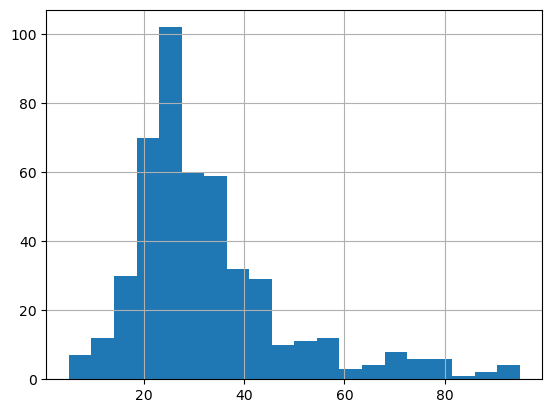

In [13]:
df['Age'].hist(bins=20)

Ages range from 5-95, no unusual entries identified.

#### Age Binning

Age was grouped into categories representing various age stages from minors to seniors.

In [14]:
age_bins = [0, 4, 12, 17, 24, 34, 44, 59, 120]
age_labels = [
    '0-4 Toddler/Early Childhood',
    '5-12 Child',
    '13-17 Teen',
    '18-24 Young Adult',
    '25-34 Adult',
    '35-44 Mature Adult',
    '45-59 Midlife',
    '60+ Senior'
]

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=age_bins,
    labels=age_labels,
    right=True,
    include_lowest=True
)

In [15]:
df['Age_Group'].value_counts(dropna=False).sort_index()

Age_Group
0-4 Toddler/Early Childhood      0
5-12 Child                      15
13-17 Teen                      23
18-24 Young Adult              125
25-34 Adult                    156
35-44 Mature Adult              73
45-59 Midlife                   42
60+ Senior                      34
NaN                            233
Name: count, dtype: int64

### Checking `Location` Values

Location values were standardized by normalizing text case, correcting known spelling issues, and removing the “County” suffix to create a clean county-level geographic field suitable for aggregation and mapping.

In [16]:
# Check all unique entries
sorted(df['Location'].dropna().unique())

['Bomet County',
 'Bomet county',
 'Bungoma County',
 'Bungoma county',
 'Busia County',
 'County',
 'Elgeyo Marakwet County',
 'Embu County',
 'Embu county',
 'Garissa County',
 'Homa Bay County',
 'Homa Bay county',
 'Homa bay county',
 'Isiolo County',
 'Kajiado County',
 'Kajiado county',
 'Kakamega County',
 'Kericho County',
 'Kericho county',
 'Kiambu County',
 'Kiambu county',
 'Kilifi County',
 'Kirinyaga County',
 'Kirinyaga county',
 'Kisii County',
 'Kisii county',
 'Kisumu County',
 'Kisumu county',
 'Kitui County',
 'Kitui county',
 'Kwale County',
 'Kwale county',
 'Laikipia County',
 'Lamu County',
 'Machakos County',
 'Machakos county',
 'Makueni County',
 'Mandera County',
 'Marsabit County',
 'Meru County',
 'Meru county',
 'Migori County',
 'Migori county',
 'Mombasa County',
 'Muranga County',
 'Nairobi County',
 'Nairobi county',
 'Nakuru',
 'Nakuru County',
 'Nakuru county',
 'Nandi County',
 'Nandi county',
 'Narok County',
 'Nyamira County',
 'Nyamira county',


In [17]:
# Standardize case first
df['Location_clean'] = (
    df['Location']
    .astype('string')
    .str.strip()
    .str.title()
)

# Fix spelling issues
location_fixes = {
    'Taita Tavet County': 'Taita Taveta County',
    'Tharaka - Nithi County': 'Tharaka-Nithi County',
    'Trans Nzoia County': 'Trans-Nzoia County',
    'County': 'Trans-Nzoia County'
}

df['Location_clean'] = df['Location_clean'].replace(location_fixes)

# Remove the word “County”
df['Location_clean'] = (
    df['Location_clean']
    .str.replace(r'\s*County$', '', regex=True)
)

In [18]:
#sorted(df['Location_clean'].dropna().unique())
df['Location_clean'].value_counts()

Location_clean
Nairobi            96
Nakuru             79
Kiambu             56
Kisumu             23
Muranga            21
Kirinyaga          20
Homa Bay           20
Kisii              19
Meru               19
Trans-Nzoia        18
Uasin Gishu        17
Machakos           17
Kajiado            16
Nyeri              15
Kakamega           15
Kericho            15
Embu               13
Kitui              12
Bungoma            12
Nandi              11
Siaya              11
Bomet              11
Nyandarua          11
Migori              9
Laikipia            8
West Pokot          8
Mombasa             7
Kwale               7
Taita Taveta        6
Elgeyo Marakwet     6
Makueni             5
Nyamira             5
Narok               5
Tharaka-Nithi       4
Isiolo              4
Kilifi              4
Busia               4
Vihiga              3
Mandera             2
Marsabit            1
Garissa             1
Wajir               1
Turkana             1
Tana River          1
Lamu             

### Checking `Suspect` column

In [19]:
# Check all unique entries
df['Suspect'].value_counts()

Suspect
Husband                          148
husband                          145
Boyfriend                        142
Stranger/Unknown Relationship    110
Family Member                     26
Friend/Known to victim            22
Ex-husband                        20
Ex-boyfriend                      11
boyfriend                         11
ex-boyfriend                       6
lover                              6
Gang                               2
step father                        2
Lover                              2
criminal                           1
04-Jul-21                          1
one of the is a lover              1
Wife to victim's lover             1
Casual labourer                    1
ex-boyfirend                       1
casual labourers                   1
ex-boyfriend, girlfriend           1
enstranged husband                 1
Rider                              1
Cousin                             1
brother                            1
ex-husband                    

#### Clean and normalize suspect values
The Suspect field was normalized to lowercase and fully standardized using an explicit value mapping to ensure consistent perpetrator classification.

**nullable string

In [20]:
# Standardize case first
df['Suspect_clean'] = (
    df['Suspect']
    .astype('string')
    .str.strip()
    .str.lower()
)

# Mapping to standardize values
suspect_fixes = {
    'husband': 'Husband',
    'boyfriend': 'Boyfriend',
    'ex-boyfirend': 'Ex-Boyfriend',
    'ex-boyfriend': 'Ex-Boyfriend',
    'enstranged husband': 'Ex-Husband',
    'ex-husband': 'Ex-Husband',
    'step father': 'Step Father',
    'brother': 'Brother',
    'cousin': 'Cousin',
    'lover': 'Lover',
    'one of the is a lover': 'Lover',
    "wife to victim's lover": "Lover's Wife",
    'casual labourers': 'Casual Labourer',
    'casual labourer': 'Casual Labourer',
    'rider': 'Rider',
    'friend/known to victim': 'Friend/Known To Victim',
    'stranger/unknown relationship': 'Stranger/Unknown relationship',
    'gang': 'Gang',
    'criminal': 'Criminal',
    'family member': 'Family Member',
    'ex-boyfriend, girlfriend': 'Ex-Boyfriend'
}

# Replace based on mapping
df['Suspect_clean'] = df['Suspect_clean'].replace(suspect_fixes)

In [21]:
# Check
df['Suspect_clean'].value_counts(dropna=False)

Suspect_clean
Husband                          293
Boyfriend                        153
Stranger/Unknown relationship    110
<NA>                              35
Family Member                     26
Friend/Known To Victim            22
Ex-Husband                        22
Ex-Boyfriend                      19
Lover                              9
Step Father                        2
Gang                               2
Casual Labourer                    2
Criminal                           1
Lover's Wife                       1
Rider                              1
Cousin                             1
Brother                            1
04-jul-21                          1
Name: count, dtype: Int64

An unusual suspect entry (‘04-jul-21’) was identified and removed as it did not represent a valid perpetrator relationship.

In [22]:
# Find index and drop
bad_idx = df.index[df['Suspect_clean'] == '04-jul-21']
df = df.drop(index=bad_idx)

In [23]:
# Check
df[df['Suspect_clean'] == '04-jul-21']

,Name,Age,Location,Date,Suspect,Verdict_time,Source_url,Age_Group,Location_clean,Suspect_clean


#### Create `suspect category`

In [24]:
# Mapping suspect values to an appropriate category
def map_suspect_category(x):
    if pd.isna(x):
        return pd.NA
    
    if x in [
        'Husband',
        'Ex-Husband',
        'Boyfriend',
        'Ex-Boyfriend',
        'Lover',
        "Lover's Wife"
    ]:
        return 'Intimate Partner'
    
    if x in [
        'Brother',
        'Cousin',
        'Step Father',
        'Family Member'
    ]:
        return 'Family Member'
    
    if x in [
        'Friend/Known To Victim',
        'Casual Labourer',
        'Rider'
    ]:
        return 'Known to Victim'
    
    return 'Stranger/ Unknown Relationship'


df['Suspect_category'] = df['Suspect_clean'].apply(map_suspect_category)

#### Validate categorisation

In [25]:
df['Suspect_category'].value_counts(dropna=False)

Suspect_category
Intimate Partner                  497
Stranger/ Unknown Relationship    113
<NA>                               35
Family Member                      30
Known to Victim                    25
Name: count, dtype: int64

In [26]:
pd.crosstab(df['Suspect_clean'], df['Suspect_category'])

Suspect_category,Family Member,Intimate Partner,Known to Victim,Stranger/ Unknown Relationship
Suspect_clean,,,,
Boyfriend,0,153,0,0
Brother,1,0,0,0
Casual Labourer,0,0,2,0
Cousin,1,0,0,0
Criminal,0,0,0,1
Ex-Boyfriend,0,19,0,0
Ex-Husband,0,22,0,0
Family Member,26,0,0,0
Friend/Known To Victim,0,0,22,0


### Check and transform `Date` column

#### Check existing date formats

Raw date strings were profiled using pattern abstraction to identify the distinct date formats present in the dataset.

In [27]:
# Replace numbers with 'D' to reveal pattern
def date_pattern(x):
    if pd.isna(x):
        return pd.NA
    return re.sub(r'\d', 'D', x)

df['Date_pattern'] = df['Date'].apply(date_pattern)

df['Date_pattern'].value_counts()

Date_pattern
DD-Jan-DD               73
DD-Mar-DD               63
DD-May-DD               59
DD-Jul-DD               59
DD-Sep-DD               55
DD-Feb-DD               55
DD-Jun-DD               55
DD-Apr-DD               49
DD-Dec-DD               49
DD-Oct-DD               47
DD-Aug-DD               40
DD-Nov-DD               36
DD-DD-DD                11
D/DD/DDDD                9
DD/DD/DDDD               8
DD Sep, DDDD             1
October D DDDD           1
Friday, July DD DDDD     1
June DD DDDD             1
January DD DDDD          1
Name: count, dtype: int64

#### Parse to datetime format

Due to the different date formats we set 'format' to 'mixed' to handle each case as required.

In [28]:
# Parse to datetime
df['Date_parsed'] = pd.to_datetime(
    df['Date'],
    errors='coerce',
    format='mixed'
)

In [29]:
# Sanity Check
df[['Date', 'Date_parsed']].sample(10)

,Date,Date_parsed
398,26-Oct-19,2019-10-26
41,28-Jan-24,2024-01-28
179,03-Feb-23,2023-02-03
64,20-May-24,2024-05-20
410,29-Jul-19,2019-07-29
171,03-Mar-23,2023-03-03
600,10-Jun-17,2017-06-10
518,22-Jul-18,2018-07-22
71,19-May-24,2024-05-19
330,19-Sep-20,2020-09-19


#### Extract Year and Month

To support trend analysis.

In [30]:
# Extract year
df['Year'] = df['Date_parsed'].dt.year

In [31]:
# Extract month name
df['Month_name'] = df['Date_parsed'].dt.month_name()

In [32]:
# Extract year and month
df['YearMonth'] = df['Date_parsed'].dt.to_period('M').astype('string')

In [33]:
# Check
df['Year'].min()

2005.0

### Keep Relevant Columns

In [34]:
# Check
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 700 entries, 0 to 700
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Name              688 non-null    object        
 1   Age               468 non-null    float64       
 2   Location          640 non-null    object        
 3   Date              673 non-null    object        
 4   Suspect           665 non-null    object        
 5   Verdict_time      57 non-null     object        
 6   Source_url        700 non-null    object        
 7   Age_Group         468 non-null    category      
 8   Location_clean    640 non-null    string        
 9   Suspect_clean     665 non-null    string        
 10  Suspect_category  665 non-null    object        
 11  Date_pattern      673 non-null    object        
 12  Date_parsed       673 non-null    datetime64[ns]
 13  Year              673 non-null    float64       
 14  Month_name        673 non-null 

In [35]:
# List of columns we want to keep in the new clean dataset
viz_cols = [
    'Name',
    'Age',
    'Age_Group',
    'Location_clean',
    'Date_parsed',
    'Year',
    'Month_name',
    'YearMonth',
    'Suspect_category',
    'Suspect_clean',
    'Verdict_time',
    'Source_url'
]

# Create new clean dataframe
df_clean = df[viz_cols].copy()

In [36]:
# Check
df_clean.head()

,Name,Age,Age_Group,Location_clean,Date_parsed,Year,Month_name,YearMonth,Suspect_category,Suspect_clean,Verdict_time,Source_url
0,<NA>,16.0,13-17 Teen,Nairobi,2024-11-29,2024.0,November,2024-11,Stranger/ Unknown Relationship,Stranger/Unknown relationship,<NA>,https://www.the-star.co.ke/news/2024-12-29-kia...
1,Julia Kerubo,23.0,18-24 Young Adult,Kisii,2024-11-15,2024.0,November,2024-11,Intimate Partner,Husband,<NA>,https://www.citizen.digital/wananchi-reporting...
2,<NA>,NaN,NaN,Nakuru,2024-12-25,2024.0,December,2024-12,Stranger/ Unknown Relationship,Stranger/Unknown relationship,<NA>,https://www.citizen.digital/news/police-probe-...
3,Gladys Thara,24.0,18-24 Young Adult,Tharaka-Nithi,2024-11-13,2024.0,November,2024-11,Intimate Partner,Husband,<NA>,https://www.the-star.co.ke/news/realtime/2024-...
4,Lilian Achieng' Aluko,NaN,NaN,Nairobi,2024-11-02,2024.0,November,2024-11,Intimate Partner,Boyfriend,<NA>,https://www.citizen.digital/news/woman-alleged...


### Check for Duplication

#### Check Overall Duplicate Rows

A duplicate scan was performed across all fields to identify any fully repeated records that may have resulted from the scraping process.

In [37]:
df_clean[df_clean.duplicated(keep=False)]

,Name,Age,Age_Group,Location_clean,Date_parsed,Year,Month_name,YearMonth,Suspect_category,Suspect_clean,Verdict_time,Source_url
14,Eunice Chepkaitany Koima,NaN,NaN,Nakuru,2024-08-08,2024.0,August,2024-08,Intimate Partner,Husband,<NA>,https://nation.africa/kenya/counties/nakuru/in...
111,Eunice Chepkaitany Koima,NaN,NaN,Nakuru,2024-08-08,2024.0,August,2024-08,Intimate Partner,Husband,<NA>,https://nation.africa/kenya/counties/nakuru/in...


In [38]:
# count fully duplicated rows
total_duplicates = df_clean.duplicated().sum()
print(f"Total fully duplicated rows: {total_duplicates}")

Total fully duplicated rows: 1







Remaining duplicate records were identified where victim details matched but suspect information conflicted across sources.
different news sources reported different suspects
	•	suspect status changed over time
	•	reporting uncertainty
	•	data entry inconsistency
    
A conflict flag was created to identify cases where multiple suspect values were reported for the same victim profile.

#### Check likely duplicates

Records that matched on Name, Age, Location, Date, and Suspect were treated as the same incident. 

In [39]:
# flag likely duplicate records based on key identity fields
likely_dupes = df_clean[
    df_clean.duplicated(subset=['Name', 'Date_parsed', 'Location_clean'], keep=False)
].sort_values(by=['Name', 'Date_parsed', 'Location_clean'])

likely_dupes

,Name,Age,Age_Group,Location_clean,Date_parsed,Year,Month_name,YearMonth,Suspect_category,Suspect_clean,Verdict_time,Source_url
481,Ann Gathoni,35.0,35-44 Mature Adult,Nairobi,2018-05-06,2018.0,May,2018-05,Intimate Partner,Boyfriend,<NA>,https://www.the-star.co.ke/news/2018-05-08-hei...
536,Ann Gathoni,35.0,35-44 Mature Adult,Nairobi,2018-05-06,2018.0,May,2018-05,Intimate Partner,Boyfriend,<NA>,http://www.the-star.co.ke/news/2018/05/08/hein...
473,Elvinah Moracha,17.0,13-17 Teen,Kisii,2018-09-23,2018.0,September,2018-09,Intimate Partner,Husband,<NA>,https://www.standardmedia.co.ke/article/200129...
509,Elvinah Moracha,17.0,13-17 Teen,Kisii,2018-09-23,2018.0,September,2018-09,Intimate Partner,Ex-Boyfriend,<NA>,http://www.standardmedia.co.ke/article/2001296...
14,Eunice Chepkaitany Koima,NaN,NaN,Nakuru,2024-08-08,2024.0,August,2024-08,Intimate Partner,Husband,<NA>,https://nation.africa/kenya/counties/nakuru/in...
111,Eunice Chepkaitany Koima,NaN,NaN,Nakuru,2024-08-08,2024.0,August,2024-08,Intimate Partner,Husband,<NA>,https://nation.africa/kenya/counties/nakuru/in...
425,Fiona Kisuya,NaN,NaN,Uasin Gishu,2019-02-26,2019.0,February,2019-02,Intimate Partner,Boyfriend,<NA>,http://www.standardmedia.co.ke/article/2001314...
427,Fiona Kisuya,25.0,25-34 Adult,Uasin Gishu,2019-02-26,2019.0,February,2019-02,Intimate Partner,Boyfriend,<NA>,http://www.the-star.co.ke/news/2019/02/27/eldo...
10,Jecinta Atieno,26.0,25-34 Adult,Kisumu,2024-07-29,2024.0,July,2024-07,Intimate Partner,Husband,<NA>,https://www.the-star.co.ke/counties/nyanza/202...
103,Jecinta Atieno,26.0,25-34 Adult,Kisumu,2024-07-29,2024.0,July,2024-07,Intimate Partner,Husband,Comitted suicide,https://www.the-star.co.ke/counties/nyanza/202...


Dupes here are found to be either conflicting in suspect or source url.

#### Drop likely duplicates

Duplicate entries differing only by source link were removed to prevent double-counting.

In [40]:
dedupe_cols = ['Name', 'Age', 'Date_parsed', 'Location_clean', 'Suspect_clean']

df_clean = df_clean.drop_duplicates(subset=dedupe_cols, keep='first')

remaining_conflicts=df_clean[df_clean.duplicated(subset=['Name', 'Age', 'Date_parsed', 'Location_clean'], keep=False)]#.sort_values(['Name','Date','Location'])
remaining_conflicts

,Name,Age,Age_Group,Location_clean,Date_parsed,Year,Month_name,YearMonth,Suspect_category,Suspect_clean,Verdict_time,Source_url
23,Serah Ndunge Musyoki,20.0,18-24 Young Adult,Nairobi,2024-01-28,2024.0,January,2024-01,Intimate Partner,Boyfriend,<NA>,https://www.the-star.co.ke/news/2024-01-29-wom...
41,Serah Ndunge Musyoki,20.0,18-24 Young Adult,Nairobi,2024-01-28,2024.0,January,2024-01,Intimate Partner,Lover,<NA>,https://www.the-star.co.ke/news/realtime/2024-...
473,Elvinah Moracha,17.0,13-17 Teen,Kisii,2018-09-23,2018.0,September,2018-09,Intimate Partner,Husband,<NA>,https://www.standardmedia.co.ke/article/200129...
485,Priscilla Wangeci,NaN,NaN,Kajiado,2018-02-11,2018.0,February,2018-02,Stranger/ Unknown Relationship,Stranger/Unknown relationship,<NA>,https://www.the-star.co.ke/news/2018-02-19-ron...
509,Elvinah Moracha,17.0,13-17 Teen,Kisii,2018-09-23,2018.0,September,2018-09,Intimate Partner,Ex-Boyfriend,<NA>,http://www.standardmedia.co.ke/article/2001296...
551,Priscilla Wangeci,NaN,NaN,Kajiado,2018-02-11,2018.0,February,2018-02,Intimate Partner,Husband,<NA>,http://www.the-star.co.ke/news/2018/02/19/rong...
558,Lucy Njambi,24.0,18-24 Young Adult,Kiambu,2018-01-26,2018.0,January,2018-01,Intimate Partner,Husband,<NA>,http://www.nation.co.ke/news/Woman-Dies-After-...
563,Lucy Njambi,24.0,18-24 Young Adult,Kiambu,2018-01-26,2018.0,January,2018-01,Intimate Partner,Ex-Husband,<NA>,https://www.standardmedia.co.ke/central/articl...
576,Yvonne Njeri,21.0,18-24 Young Adult,Kiambu,2017-09-16,2017.0,September,2017-09,Intimate Partner,Boyfriend,<NA>,https://www.standardmedia.co.ke/article/200125...
598,Yvonne Njeri,21.0,18-24 Young Adult,Kiambu,2017-09-16,2017.0,September,2017-09,Stranger/ Unknown Relationship,Stranger/Unknown relationship,<NA>,http://www.standardmedia.co.ke/article/2001254...


#### Resolving suspect conflicts

A small number of records showed conflicting suspect information across sources. These cases were manually reviewed and resolved using predefined override mapping before final deduplication.

#### Create a stable victim key
A composite victim key was created using Name, Location, and Date to uniquely identify records during conflict resolution.

In [41]:
df_clean['victim_key'] = (
    df_clean['Name'].astype(str) + "|" +
    df_clean['Location_clean'].astype(str) + "|" +
    df_clean['Date_parsed'].astype(str)
)

A reusable override function was implemented to systematically resolve conflicting records across multiple columns using key-based mapping.

In [42]:
def apply_overrides(df, key_col, target_col, keys, values):
    """
    Apply manual override values to a target column based on a key column.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame to modify
    key_col : str
        Column used to match records (e.g., 'victim_key')
    target_col : str
        Column to overwrite (e.g., 'Suspect_clean')
    keys : list
        List of key values to match
    values : list
        List of replacement values (same order as keys)

    Returns
    -------
    pandas.DataFrame
        Updated dataframe
    """
    
    override_map = dict(zip(keys, values))
    mask = df[key_col].isin(override_map.keys())
    
    df.loc[mask, target_col] = (
        df.loc[mask, key_col].map(override_map)
    )
    
    return df

In [43]:
# Keys from reviewed cases
override_keys = [
    "Serah Ndunge Musyoki|Nairobi|2024-01-28",
    "Elvinah Moracha|Kisii|2018-09-23",
    "Priscilla Wangeci|Kajiado|2018-02-11",
    "Lucy Njambi|Kiambu|2018-01-26",
    "Yvonne Njeri|Kiambu|2017-09-16"
]

# Apply to Suspect_clean
override_values_clean = [
    "Boyfriend",
    "Ex-Boyfriend",
    "Husband",
    "Husband",
    "Stranger/Unknown relationship"
]

df_clean = apply_overrides(
    df_clean,
    key_col='victim_key',
    target_col='Suspect_clean',
    keys=override_keys,
    values=override_values_clean
)

The suspect category, in turn, also needs to be updated.

In [44]:
# Apply to Suspect_category
override_values_category = [
    "Intimate Partner",
    "Intimate Partner",
    "Intimate Partner",
    "Intimate Partner",
    "Stranger/ Unknown Relationship"
]

df_clean = apply_overrides(
    df_clean,
    key_col='victim_key',
    target_col='Suspect_category',
    keys=override_keys,
    values=override_values_category
)

In [45]:
# Deduplicate
df_clean = df_clean.drop_duplicates(
    subset=['Name','Age','Location_clean','Date_parsed'],
    keep='first'
).copy()

#Sanity Check
df_clean.duplicated(
    subset=['Name','Age','Location_clean','Date_parsed']
).sum()

0

### Back to missing

Now that we are done cleaning, we go back to the missing values to handle them in a way that is best for analysis:
Numerical fields such as age and dates were left null to preserve data integrity, while categorical fields were labeled as “Unknown” to maintain transparency and consistency.

Text fields were converted to pandas nullable string dtype to ensure consistent missing value handling.

In [46]:
# Convert to nullable string
df_clean = df_clean.astype({
    'Name': 'string',
    'Month_name': 'string',
    'Suspect_category': 'string',
    'Verdict_time': 'string',
    'Source_url': 'string',
    'victim_key': 'string',
    'Age_Group': 'string'
})

In [47]:
# Missing values flagged as 'Unknown' for categorical columns
df_clean['Name'] = df_clean['Name'].fillna('Unknown')
df_clean['Age_Group'] = df_clean['Age_Group'].fillna('Unknown')
df_clean['Verdict_time'] = df_clean['Verdict_time'].fillna('Unknown')
df_clean['Location_clean'] = df_clean['Location_clean'].fillna('Unknown')
df_clean['Suspect_clean'] = df_clean['Suspect_clean'].fillna('Unknown')
df_clean['Suspect_category'] = df_clean['Suspect_category'].fillna('Unknown')

### Final quality check and save to csv

Confirm we have the right columns and in the correct datatype

In [48]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 687 entries, 0 to 700
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Name              687 non-null    string        
 1   Age               458 non-null    float64       
 2   Age_Group         687 non-null    string        
 3   Location_clean    687 non-null    string        
 4   Date_parsed       660 non-null    datetime64[ns]
 5   Year              660 non-null    float64       
 6   Month_name        660 non-null    string        
 7   YearMonth         660 non-null    string        
 8   Suspect_category  687 non-null    string        
 9   Suspect_clean     687 non-null    string        
 10  Verdict_time      687 non-null    string        
 11  Source_url        687 non-null    string        
 12  victim_key        687 non-null    string        
dtypes: datetime64[ns](1), float64(2), string(10)
memory usage: 75.1 KB


In [49]:
df_clean = df_clean.sort_values('Date_parsed')
df_clean.to_csv('femicide_clean.csv', index=False)